# Modelling patch-clamp experiments: simplified models

In the [previous notebook](./3-simulations.ipynb) we showed how our model of the patch-clamp set up can be used to simulate experiments in detail.
In this notebook, we explore how the model can be simplified, making it easier to understand, implement, and use.
Simplified models also have performance benefits, which is useful when performing parameter inference.

## Level 0: The full model

First, we recapitulate the full, unsimplified model.

<img src="./img/vc-level-0.png" />

_**Figure 1**: The "Level 0" unsimplified model._

\begin{align}
3.0.1. && C_m\dot{V}_m = \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I
\end{align}

\begin{align}
3.0.2. && (C_p+\tilde{C}_f)\dot{V}_p = \frac{V_o - V_p}{R_f} - \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} + \tilde{C}_f\dot{V}_o + C_m^* \dot{V}_e + C_p^* \dot{V}_r
\end{align}

\begin{align}
3.0.3. && \tau_a \dot{V}_o = V_r - V_p
\end{align}

\begin{align}
3.0.4. && V_r = V_s + \alpha \frac{R_s^*}{R_f} V_\text{rc} + \beta R_s^* C_m^* \dot{V}_e
              = \alpha \frac{R_s^*}{R_f} V_\text{rc} + \frac{V_s - \beta V_e}{1 - \beta}
\end{align}

\begin{align}
3.0.5. && \dot{V}_e &= \frac{V_s - V_e}{(1 - \beta)R_s^*C_m^*}   
\end{align}

\begin{align}
3.0.6. && \tau_\text{rc} \dot{V}_\text{rc} = V_1 - V_\text{rc}
\end{align}

\begin{align}
3.0.7. && \dot{V_s} = f_s(V_c, V_s)
\end{align}

\begin{align}
3.0.8. && \dot{V}_1 = f_1(V_o - V_r, V_1)
\end{align}

\begin{align}
3.0.9. && \dot{V}_2 = f_2(V_1, V_2)
\end{align}

\begin{align}
3.0.10. && I_\text{obs} = V_2 / R_f
\end{align}

To see where we can simplify, we will simulate a single, large step from -140mV to +60mV and plot the main variables (e.g. $V_m$, $I_\text{obs}$) and the fastest changing states.
To make this easier, we added a function `simplification_plot` to `library.py`.

Instead of writing out the model equations again, we will load them from a file name `vc-level-0.mmt`.
We will call this this first, unsimplified, version the "level 0 model".

In [1]:
import myokit
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Import function from shared library
import sys
sys.path.insert(0, 'src')
from library import simplification_plot1 as plot1
from library import simplification_plot2 as plot2

In [2]:
m0 = myokit.load_model('../models-mmt/vc-level-0.mmt')
m0.check_units(myokit.UNIT_STRICT)

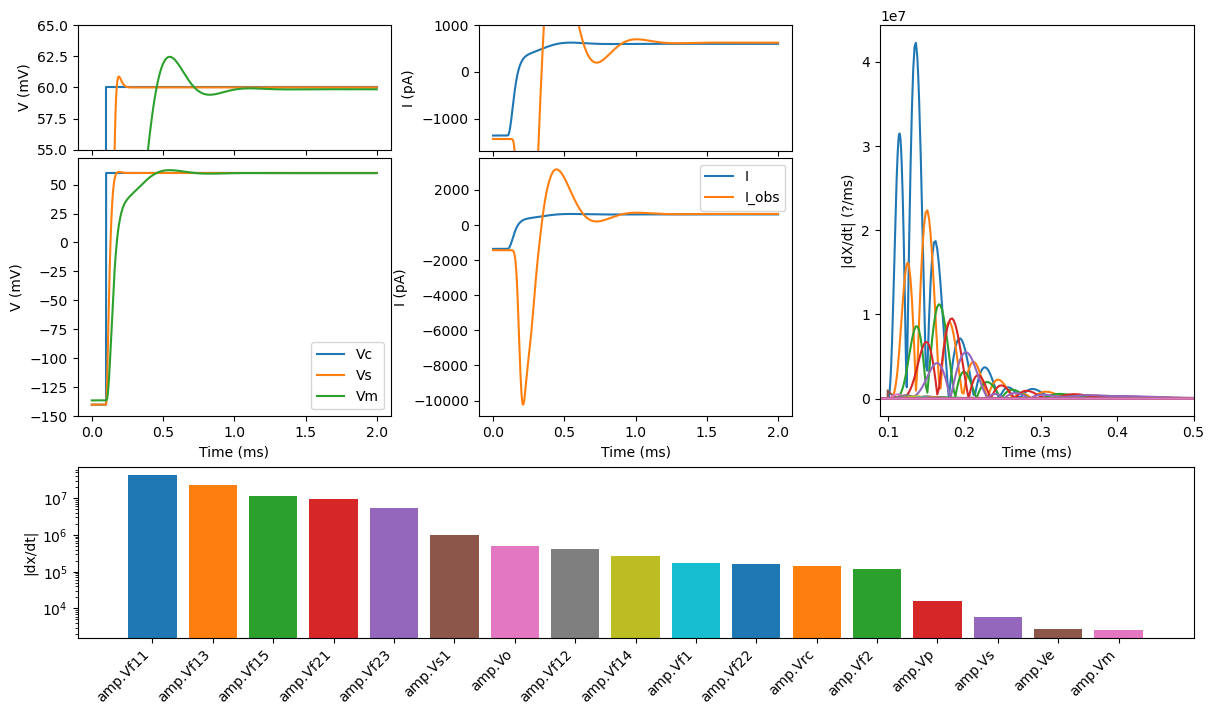

In [3]:
fig, axes = plot1(m0)

This shows that the fastest changes are mostly due to the filters: The top six is entirely due to filters, and 13 out of the 15 fastest states are related to filtering.

For the higher-order filters (filter1, filter2, and the stimulus filter) we can also see that the output state ($V_{f1}$, $V_{f2}$, $V_s$) is always the slowest: we can think of the higher orders as adding "details" to a process dominated by the output state.

## Level 1: First-order filters

To simplify the filtering, we now

- Combine $F_1$ and $F_2$ into a single, 1-pole output filter with time constant $\tau_o$
- Combine $F_1$ and $F_\text{rc}$ into a single, 1-pole filter with time constant $\tilde{\tau}_\text{rc}$
- Represent the two-pole stimulus filter with a 1-pole filter with time constant $\tau_s$


<img src="./img/vc-level-1.png" />

_**Figure 2**: The Level 1 schematic, with simplified 1-pole filters._

\begin{align}
3.1.1. && C_m\dot{V}_m = \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I
\end{align}

\begin{align}
3.1.2. && (C_p+\tilde{C}_f)\dot{V}_p = \frac{V_o - V_p}{R_f} - \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} + \tilde{C}_f\dot{V}_o + C_m^* \dot{V}_e + C_p^* \dot{V}_r
\end{align}

\begin{align}
3.1.3. && \tau_a \dot{V}_o = V_r - V_p
\end{align}

\begin{align}
3.1.4. && V_r = V_s + \alpha \frac{R_s^*}{R_f} V_\text{rc} + \beta R_s^* C_m^* \dot{V}_e
              = \alpha \frac{R_s^*}{R_f} V_\text{rc} + \frac{V_s - \beta V_e}{1 - \beta}
\end{align}

\begin{align}
3.1.5. && \dot{V}_e &= \frac{V_s - V_e}{(1 - \beta)R_s^*C_m^*}   
\end{align}

\begin{align}
3.1.6. && \tilde{\tau}_\text{rc} \dot{V}_\text{rc} = V_o - V_r - V_\text{rc}
\end{align}

\begin{align}
3.1.7. && \tau_s \dot{V_s} = V_c - V_s
\end{align}

\begin{align}
3.1.8. && \tau_o \dot{V}_\text{obs} = V_o - V_r - V_\text{obs}
\end{align}

\begin{align}
3.1.9. && I_\text{obs} = V_\text{obs} / R_f
\end{align}

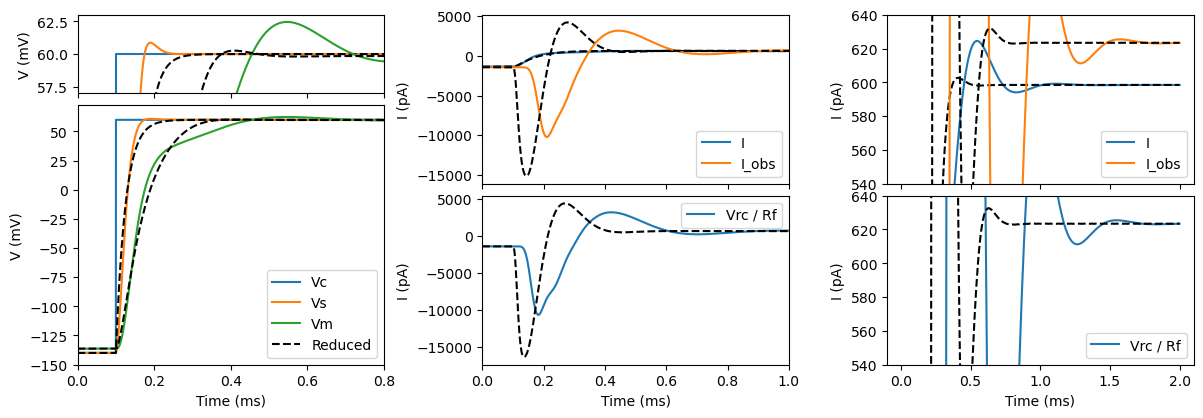

In [4]:
m1 = myokit.load_model('../models-mmt/vc-level-1.mmt')
fig, axes = plot2(m0, m1)

In the left panels, we can see the approximation of the stimulus filter in orange: the approximation is clearly simpler, rising a bit slower and lacking an overshoot. However, the difference is very shortlived.
Correspondingly, the ionic current $I$ in the top middle and top right panel is mostly unchanged.

In the right and middle panels we we can see that $I_\text{obs}$ now changes more rapidly (less filtering) and that accordingly the current fed into the series resistance compensation ($V_\text{rc} / R_f$) changes more rapidly.

We can compensate for the removal of filter 1 from the series resistance pathway by increasing the time constant $\tau_\text{rc}$:

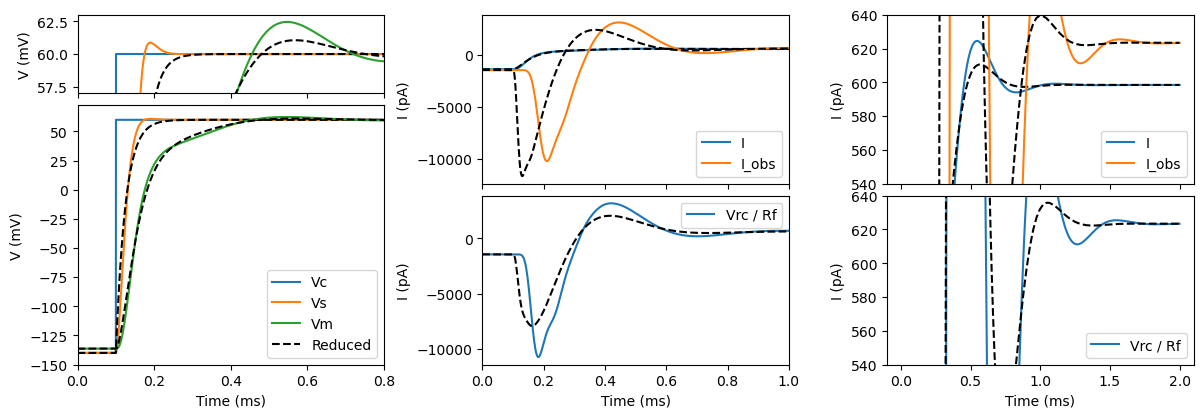

In [5]:
m1.get('amp.tau_rc').set_rhs('50e-3 [ms]')
fig, axes = plot2(m0, m1)

Note how this affects $V_\text{rc}$ strongly, while its effect on $I_\text{obs}$ is very short-lived.

We can call `plot1` again to see how the fastest states have changed:

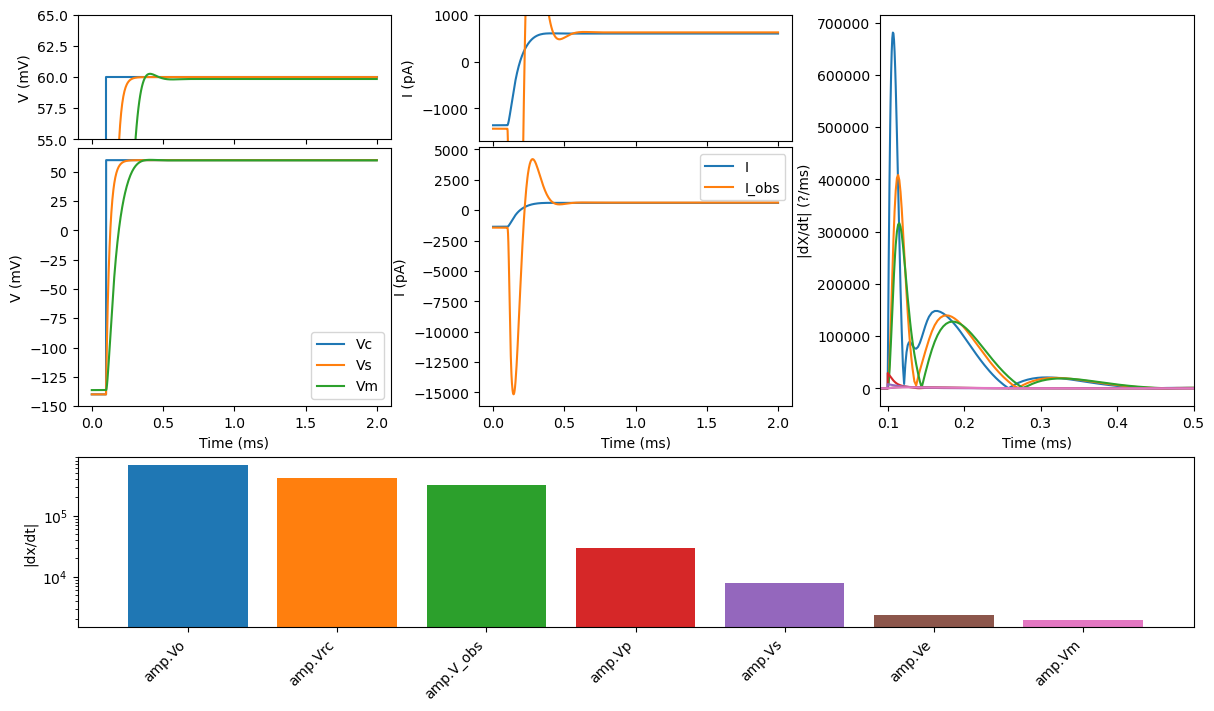

In [6]:
m1 = myokit.load_model('../models-mmt/vc-level-1.mmt')
fig, axes = plot1(m1)

We have gone a few orders of magnitude, revealing $V_o$ as the new bottleneck, followed closely by $V_\text{rc}$.

## Level 2: Ideal op-amp and no stray capacitance

To address the new bottleneck, we'll try to use the ideal op amp assumptions instead of writing an equation for $V_o$.
We'll also drop the stray capacitance $C_f$, which was introduced to model effects of finite op-amp speed.

### Level 2x: Idealising the op-amp, but keeping stray capacitance

We start by looking at the equation for $\dot{V}_o$:
\begin{align}
\dot{V}_o = \frac{V_r - V_p}{\tau_a}
\end{align}
To simplify we set $V_p = V_r$ and remove the ODE for $V_p$ from the system.
Next, we use $\dot{V}_p = \dot{V}_r$ to find a new equation for $V_o$ as:
\begin{align}
C_f \dot{V}_o = \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - \frac{V_o - V_r}{R_f} + (C_f + C_p - C_p^*) \dot{V}_r - C_m^* \dot{V}_e
\end{align}

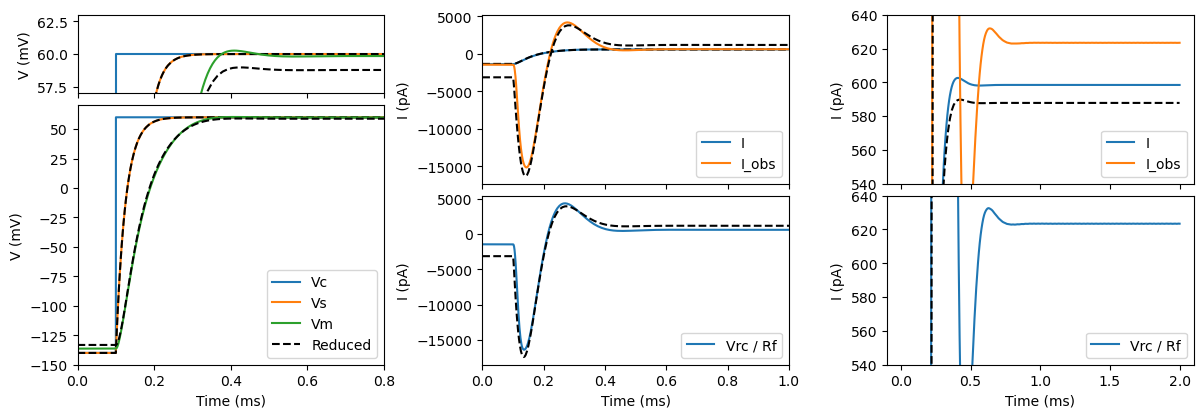

In [7]:
m2x = myokit.load_model('./res/vc-level-2x.mmt')
fig, axes = plot2(m1, m2x)

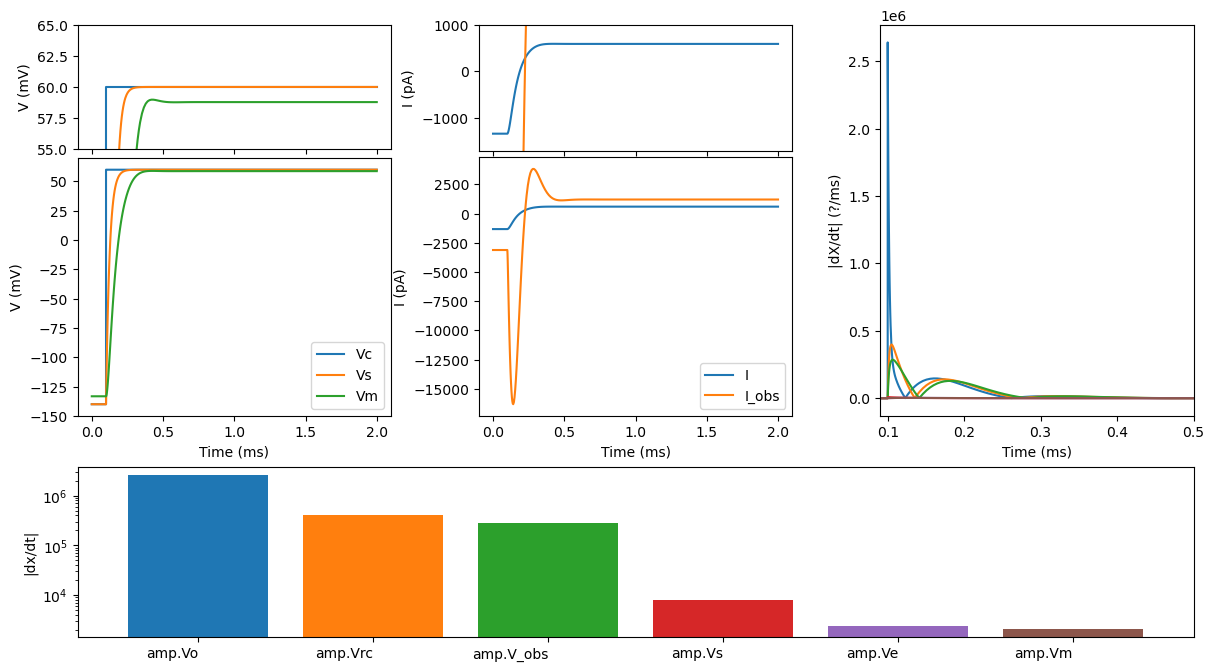

In [8]:
fig, axes = plot1(m2x)

Although we've removed a small time constant and a state, leaving out the "delay" caused by the amplifier has made the system even faster.

### Level 2y: Keeping the non-ideal op-amp, but removing stray capacitance

Next, we look at the effect of setting $C_f = 0$, which amounts to simply removing the $C_f$ terms from the equation for $V_p$:

\begin{align}
C_p \dot{V}_p = \frac{V_o - V_p}{R_f} - \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} + C_m^* \dot{V}_e + C_p^* \dot{V}_r
\end{align}

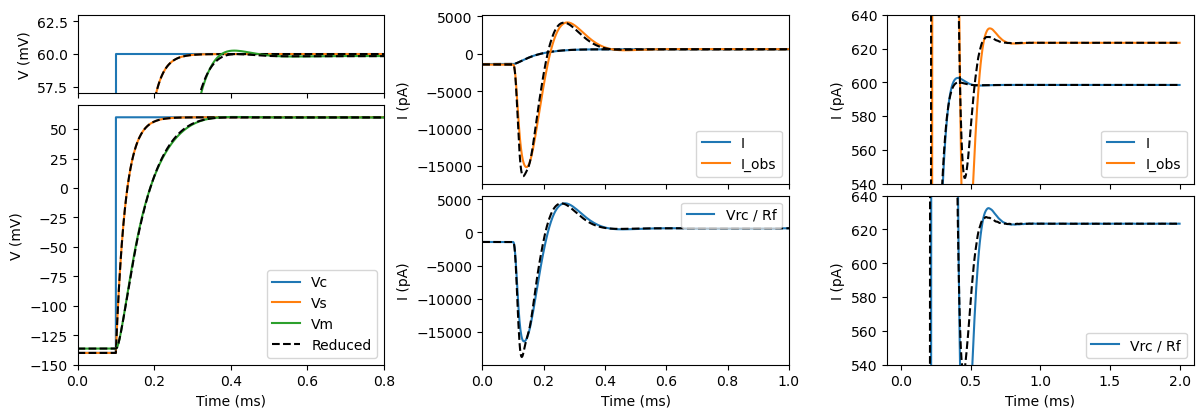

In [9]:
m2y = myokit.load_model('./res/vc-level-2y.mmt')
fig, axes = plot2(m1, m2y)

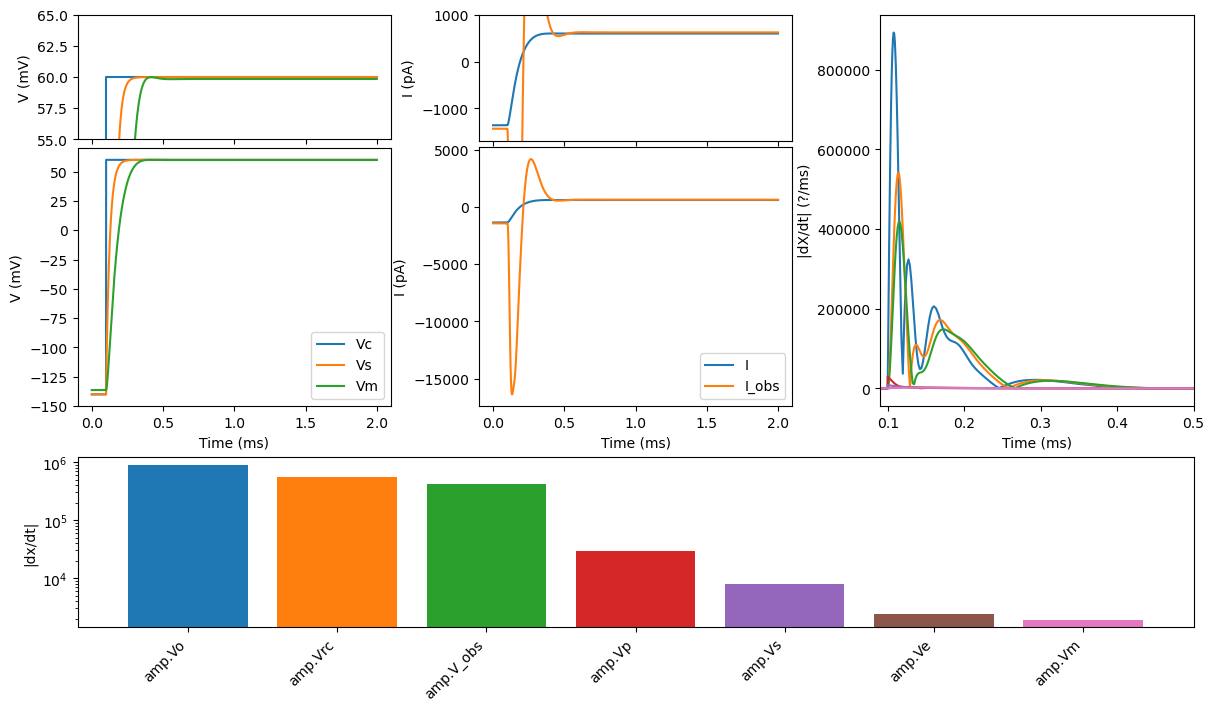

In [10]:
fig, axes = plot1(m2y)

This makes the model simpler but only slightly quicker.

### Level 2: Ideal op-amp and no stray capacitance

Next, we remove $C_f$ _and_ use the ideal op-amp assumption:

<img src="./img/vc-level-2.png" />

_**Figure 2**: The Level 2 schematic:_ $C_f$ _has been removed and the op-amp is assumed ideal._

To find a new equation for $V_o$, we can try using the current through $R_f$
\begin{align}
\frac{V_o - V_r}{R_f} &= \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} + (C_p - C_p^*) \dot{V_r} - C_m^* \dot{V_e}
\end{align}
But rewriting this as an equation for $V_o$ does not immediately result a solvable system, because the right-hand side contains $\dot{V}_r$, which depends on $\dot{V}_\text{rc}$, which depends on $V_o$ again.
Instead, we need to combine the equations for $V_o$, $V_r$ and $\dot{V}_\text{rc}$ and rearrange.

First, we write the equation above as
\begin{align}
\frac{V_o - V_r}{R_f} = I_1 + (C_p - C_p^*) \dot{V_r}
\end{align}
where
\begin{align}
I_1 &= \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - C_m^* \dot{V_e}
\end{align}

With this, the equation for $\dot{V}_\text{rc}$ becomes
\begin{align}
\tau_\text{rc} \dot{V}_\text{rc} 
    = V_o - V_r - V_\text{rc}
    = R_f I_1 - V_\text{rc} + R_f (C_p - C_p^*) \dot{V}_r
\end{align}

Next we fill in $\dot{V}_r$ to find
\begin{align}
\tau_\text{rc} \dot{V}_\text{rc} 
    &= R_f I_1 - V_\text{rc} + R_f (C_p - C_p^*) \left(\alpha \frac{R_s^*}{R_f} \dot{V}_\text{rc} + \frac{\dot{V}_s - \beta \dot{V}_e}{1 - \beta} \right) \\
    &= R_f I_1 - V_\text{rc} + \alpha R_s^* (C_p - C_p^*) \dot{V}_\text{rc} + R_f (C_p - C_p^*) \frac{\dot{V}_s - \beta \dot{V}_e}{1 - \beta} \\
    &= R_f I_1 - V_\text{rc} + a \dot{V}_\text{rc} + b
\end{align}
where
\begin{align}
a &= \alpha R_s^* (C_p - C_p^*) \\
b &= R_f (C_p - C_p^*) \frac{\dot{V}_s - \beta \dot{V}_e}{1 - \beta}
\end{align}
from which we can solve for $\dot{V}_\text{rc}$ to get
\begin{align}
\dot{V}_\text{rc} = \frac{R_f I_1 + b - V_\text{rc}}{(\tau_\text{rc} - a)}
\end{align}

At this point, the only appearance of $V_o$ is in the equation for $\dot{V}_\text{obs}$ which we rewrite as
\begin{align}
\tau_o \dot{V}_\text{obs} = V_o - V_r - V_\text{obs} = R_f I_1 + R_f (C_p - C_p^*) \dot{V_r} - V_\text{obs}
\end{align}
To comlete the model, we divide both sides by $R_f$ to find
\begin{align}
\tau_o \dot{I}_\text{obs} =  I_1 + (C_p - C_p^*) \dot{V_r} - I_\text{obs}
\end{align}

#### Level 2 equations

\begin{align}
3.2.1. && C_m\dot{V}_m = \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I
\end{align}

\begin{align}
3.2.2. && V_r = V_s + \alpha \frac{R_s^*}{R_f} V_\text{rc} + \beta R_s^* C_m^* \dot{V}_e
              = \alpha \frac{R_s^*}{R_f} V_\text{rc} + \frac{V_s - \beta V_e}{1 - \beta}
\end{align}

\begin{align}
3.2.3. && \dot{V}_e &= \frac{V_s - V_e}{(1 - \beta)R_s^*C_m^*}   
\end{align}

\begin{align}
3.2.4 && I_1 &= \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - C_m^* \dot{V_e}
\end{align}

\begin{align}
3.2.5 && \dot{V}_\text{rc} &= \frac{R_f I_1 + b - V_\text{rc}}{(\tau_\text{rc} - a)} \\
      && a &= \alpha R_s^* (C_p - C_p^*) \\
      && b &= R_f (C_p - C_p^*) \frac{\dot{V}_s - \beta \dot{V}_e}{1 - \beta}
\end{align}

\begin{align}
3.2.6. && \tau_s \dot{V_s} = V_c - V_s
\end{align}

\begin{align}
3.2.7. && \tau_o \dot{I}_\text{obs} = I_1 + (C_p - C_p^*) \dot{V}_r - I_\text{obs}
\end{align}

In equation 3.2.7, we can now clearly see how a remaining capacitance $C_p - C_p^*$ causes the familiar transient spikes in the observed current.

But more interestingly, $C_p - C_p^*$ shows up prominently in the equation for the series resistance compensation.
Here, it adds an error term ($b$), but also reduces the apparent time constant from $\tau_\text{rc}$ to $\tau_\text{rc} - a$, making the series resistance compensation system more likely to oscillate.

We can now finally run some simulations, and compare them to the Level 1 results.

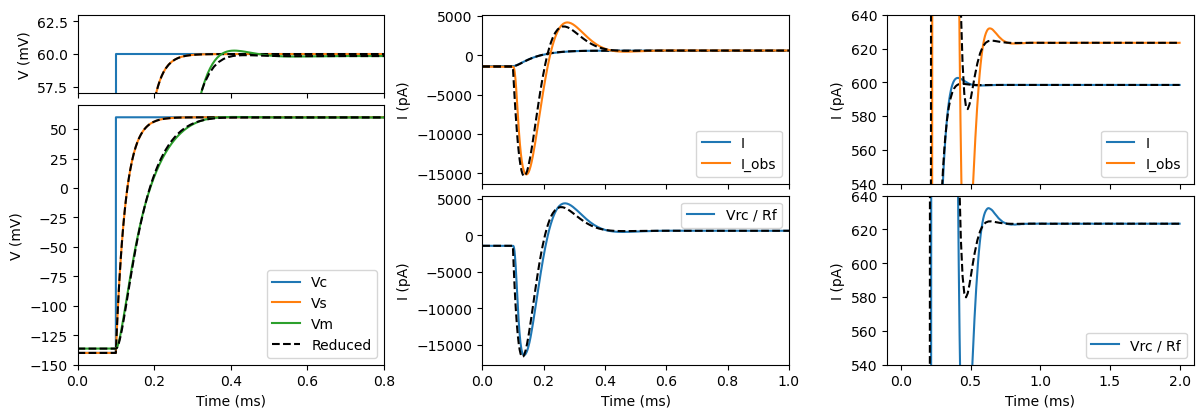

In [11]:
m2 = myokit.load_model('../models-mmt/vc-level-2.mmt')
fig, axes = plot2(m1, m2)

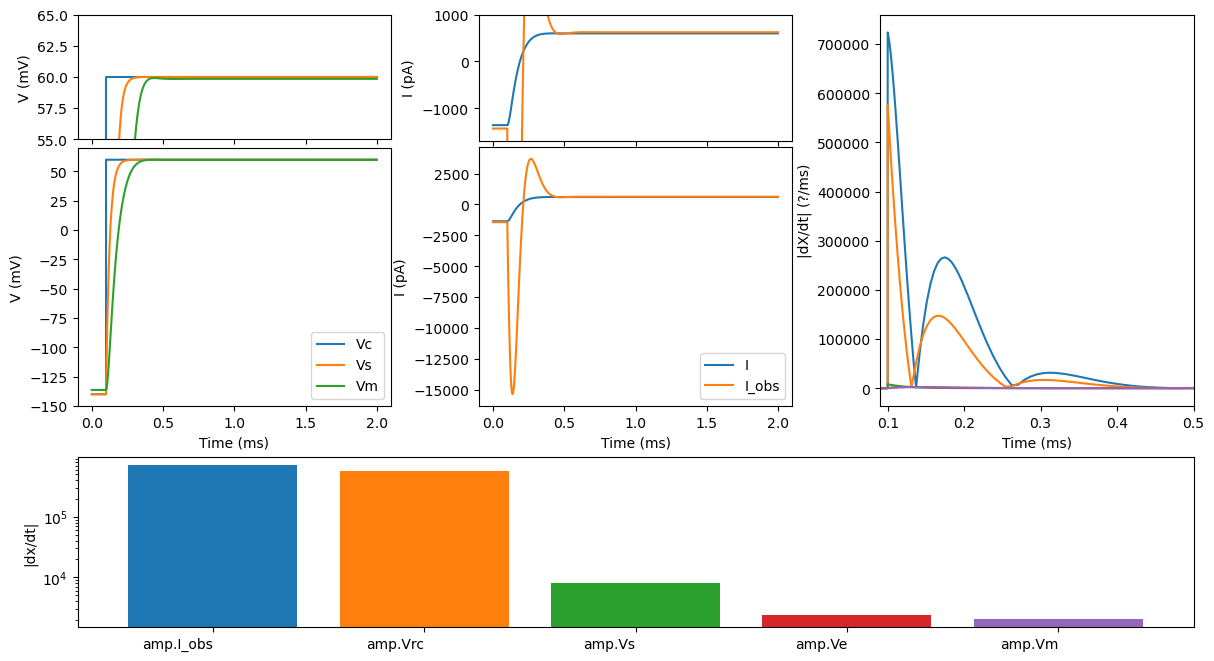

In [12]:
fig, axes = plot1(m2)

We see that the level 2 result is almost identical to level 1.
However, the system has become slightly "slower", with $V_\text{rc}$ becoming the new fastest variable.

## Level 3: Removing pipette/parasitic capacitance

In the next step, we remove $C_p$ and its compensation circuitry.

<img src="./img/vc-level-3.png" />

_**Figure 3**: Level 3 schematic: the pipette capacitance and its compensation have been removed._

The equations for this version are easily derived from level 2, by setting $C_p = C_p^*$:

\begin{align}
3.3.1. && C_m\dot{V}_m = \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I
\end{align}

\begin{align}
3.3.2. && V_r = V_s + \alpha \frac{R_s^*}{R_f} V_\text{rc} + \beta R_s^* C_m^* \dot{V}_e
              = \alpha \frac{R_s^*}{R_f} V_\text{rc} + \frac{V_s - \beta V_e}{1 - \beta}
\end{align}

\begin{align}
3.3.3. && \dot{V}_e &= \frac{V_s - V_e}{(1 - \beta)R_s^*C_m^*}   
\end{align}

\begin{align}
3.3.4 && I_1 &= \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - C_m^* \dot{V_e}
\end{align}

\begin{align}
3.3.5 && \tau_\text{rc} \dot{V}_\text{rc} &= R_f I_1 - V_\text{rc}
\end{align}

\begin{align}
3.3.6. && \tau_s \dot{V_s} = V_c - V_s
\end{align}

\begin{align}
3.3.7. && \tau_o \dot{I}_\text{obs} = I_1 - I_\text{obs}
\end{align}

The model is implemented in `vc-level-3.mmt`.

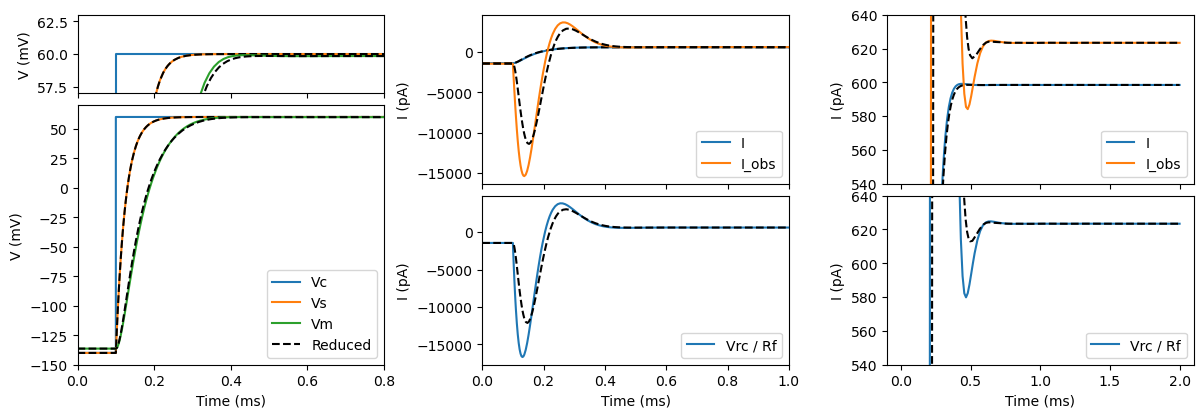

In [13]:
m3 = myokit.load_model('../models-mmt/vc-level-3.mmt')
fig, axes = plot2(m2, m3)

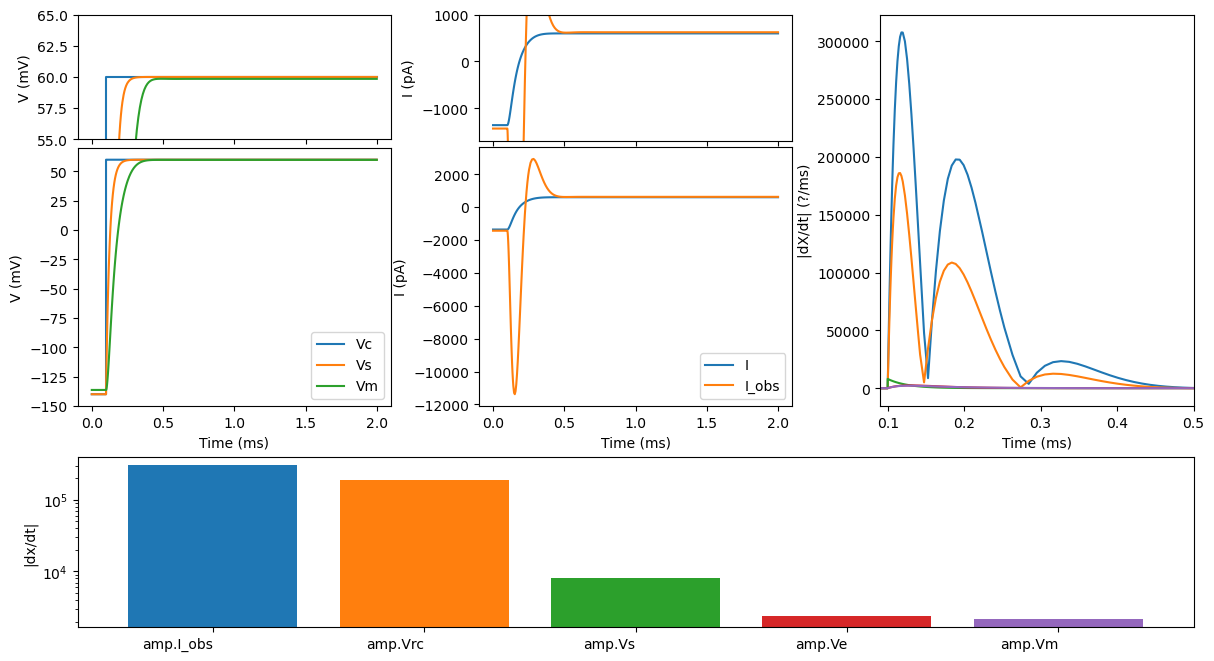

In [14]:
fig, axes = plot1(m3)

As expected, the transient current at the step change is somewhat diminished.

In addition, $I_\text{obs}$ and $V_\text{rc}$ have slightly slowed down.

## Level 4: No more filters

For slower currents, we can omit the filters on the input, output, and series resistance compensation loop.

<img src="./img/vc-level-4.png" />

_**Figure 4**: Level 4 schematic: the filters on input, output, and series resistance compensation have been removed._

Removing the output filter we get $I_\text{obs} = I_1$ so that
\begin{align}
I_\text{obs} = \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - C_m^* \dot{V_e}
\end{align}
which we can now combine with
\begin{align}
C_m\dot{V}_m = \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I
\end{align}
for
\begin{align}
I_\text{obs} = I + I_\text{leak} + C_m\dot{V}_m - C_m^* \dot{V_e}
\end{align}

Next, removing the stimulus filter we obtain $V_s = V_c$, and removing the series resistance filter results in $V_\text{rc} = R_f I_1 = R_f I_\text{obs}$, so that $V_r$ becomes
\begin{align}
V_r &= V_s + \alpha \frac{R_s^*}{R_f} V_\text{rc} + \beta R_s^* C_m^* \dot{V}_e \\
    &= V_c + \alpha R_s^* I_\text{obs} + \beta R_s^* C_m^* \dot{V}_e \\
    &= V_c + \alpha R_s^* (I + I_\text{leak}) + \alpha R_s^* C_m\dot{V}_m - (\alpha - \beta) R_s^* C_m^* \dot{V}_e
\end{align}
And we can fill this in the equation for $C_m\dot{V}_m$ to find
\begin{align}
C_m\dot{V}_m &= \frac{V_r + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I \\
             &= \frac{V_c + E_\text{off}^\dagger - V_m}{R_s} + \alpha \frac{R_s^*}{R_s} (I_\text{leak} + I) + \alpha \frac{R_s^*}{R_s} C_m\dot{V}_m - (\alpha - \beta) \frac{R_s^*}{R_s} C_m^* \dot{V}_e - I_\text{leak} - I \\
(1 - \alpha \frac{R_s^*}{R_s}) C_m\dot{V}_m &= \frac{V_c + E_\text{off}^\dagger - V_m - (\alpha - \beta) R_s^* C_m^* \dot{V}_e}{R_s} - (1 - \alpha \frac{R_s^*}{R_s}) (I + I_\text{leak}) \\
C_m\dot{V}_m &= \frac{V_c + E_\text{off}^\dagger - V_m - (\alpha - \beta) R_s^* C_m^* \dot{V}_e}{R_s - \alpha R_s^*} - I_\text{leak} - I
\end{align}
which gives us the full model:

\begin{align}
4.4.1. && C_m\dot{V}_m = \frac{V_c + E_\text{off}^\dagger - V_m - (\alpha - \beta) R_s^* C_m^* \dot{V}_e}{R_s - \alpha R_s^*} - I_\text{leak} - I
\end{align}

\begin{align}
4.4.2. && \dot{V}_e &= \frac{V_c - V_e}{(1 - \beta) R_s^* C_m^*}   
\end{align}

\begin{align}
4.4.3. && I_\text{obs} = I + I_\text{leak} + C_m \dot{V}_m - C_m^* \dot{V}_e
\end{align}

In the denominator of 4.4.1, we can see the effect of series resistance compensation, which has reduced the series resistance from $R_s$ to $R_s - \alpha R_s^*$.

The need for series resistance prediction is visible in the numerator: using $\alpha > 0$ with $\beta = 0$ would result in an additiona distorting term.

We'll first compare this to a Level 3 model with default settings:

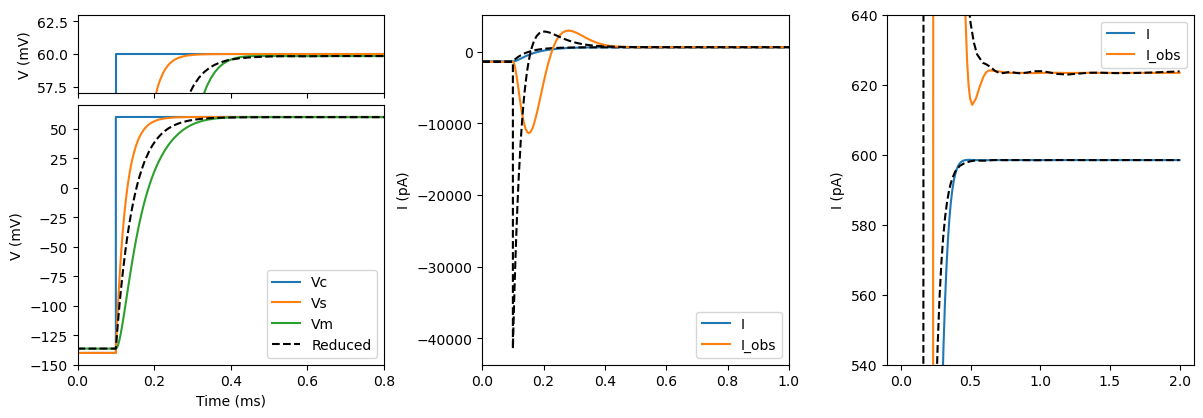

In [15]:
m4 = myokit.load_model('../models-mmt/vc-level-4.mmt')
fig, axes = plot2(m3, m4)

To check that the differences are only in the filtering, we'll also compare with very high cut-off frequencies:

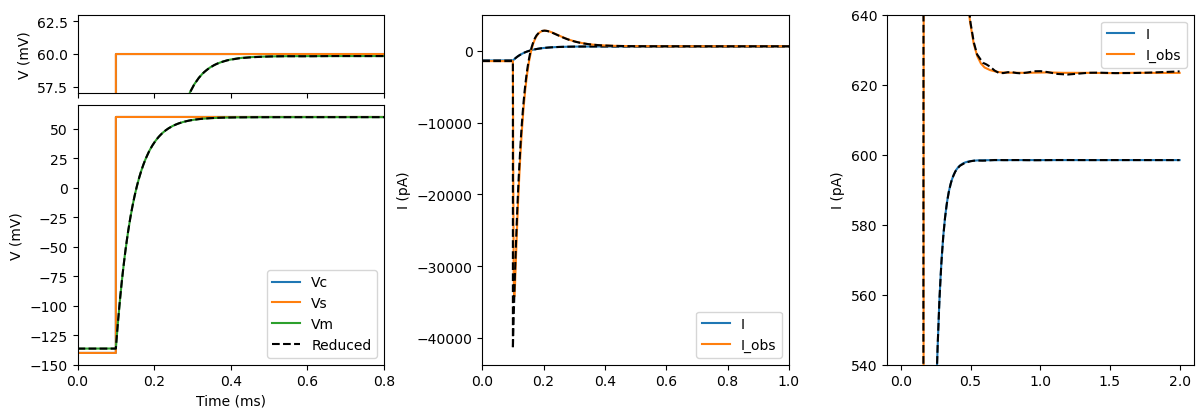

In [16]:
m3b = m3.clone()
m3b.get('amp.fo').set_rhs(100)
m3b.get('amp.tau_rc').set_rhs(1e-6)
m3b.get('amp.tau_s').set_rhs(1e-6)
    
m4 = myokit.load_model('../models-mmt/vc-level-4.mmt')
fig, axes = plot2(m3b, m4)

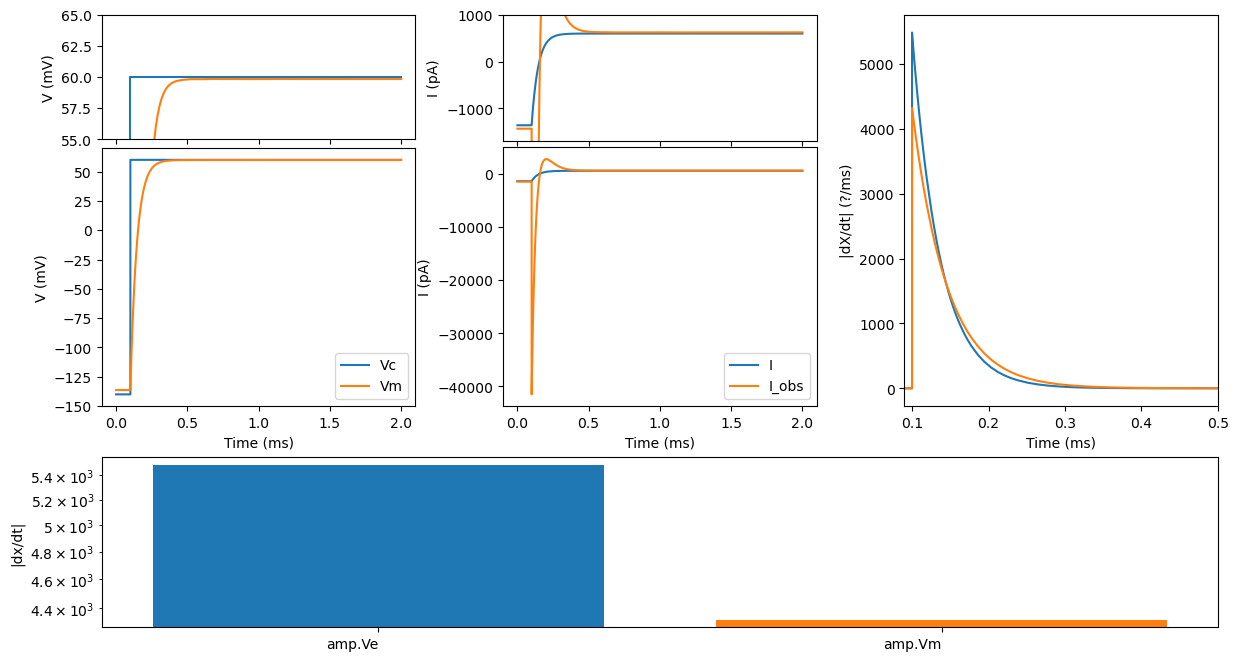

In [17]:
fig, axes = plot1(m4)

## Level 5: Perfect estimates

Finally, we get rid of $V_e$ by assuming that $R_s^* = R_s$, $C_m^* = C_m$, and $\dot{V}_e = \dot{V}_m$.

With this, the $C_m\dot{V}_m$ equation becomes
\begin{align}
C_m\dot{V}_m &= \frac{V_c + E_\text{off}^\dagger - V_m}{R_s(1 - \alpha)} - \frac{\alpha - \beta}{1 - \alpha}C_m \dot{V}_m - I_\text{leak} - I \\
(1 + \frac{\alpha - \beta}{1 - \alpha}) C_m\dot{V}_m &= \frac{1 - \beta}{1 - \alpha} C_m\dot{V}_m = \frac{V_c + E_\text{off}^\dagger - V_m}{R_s(1 - \alpha)} - I_\text{leak} - I \\
C_m\dot{V}_m &= \frac{V_c + E_\text{off}^\dagger - V_m}{R_s(1 - \beta)} - \frac{1 - \alpha}{1 - \beta}(I_\text{leak} + I)
\end{align}

And the model reduces to

\begin{align}
4.5.1. && C_m \dot{V}_m = \frac{V_c + E_\text{off}^\dagger - V_m}{(1 - \beta) R_s} - \frac{1 - \alpha}{1 - \beta}(I + I_\text{leak})
\end{align}

\begin{align}
4.5.2. && I_\text{obs} = I + I_\text{leak}
\end{align}


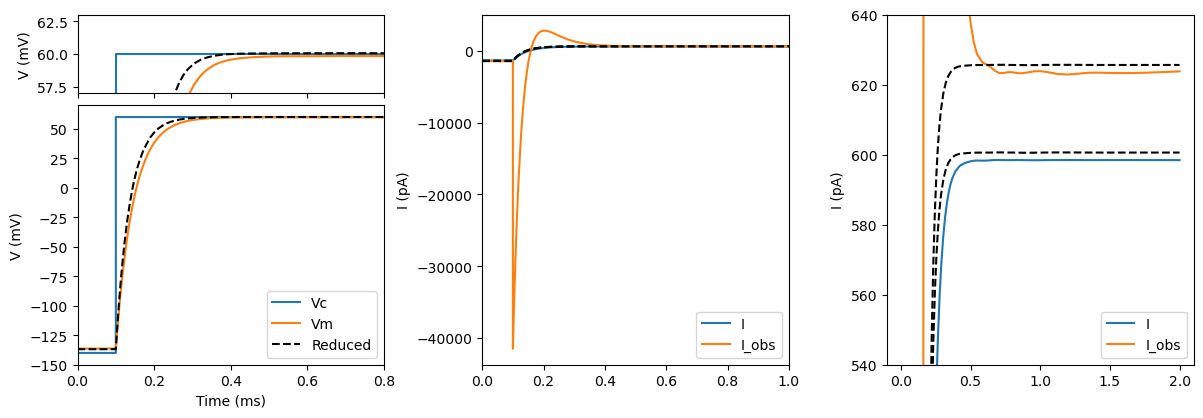

In [18]:
m5 = myokit.load_model('../models-mmt/vc-level-5.mmt')
fig, axes = plot2(m4, m5)

And finally $V_m$ has become the fastest (and only) variable.

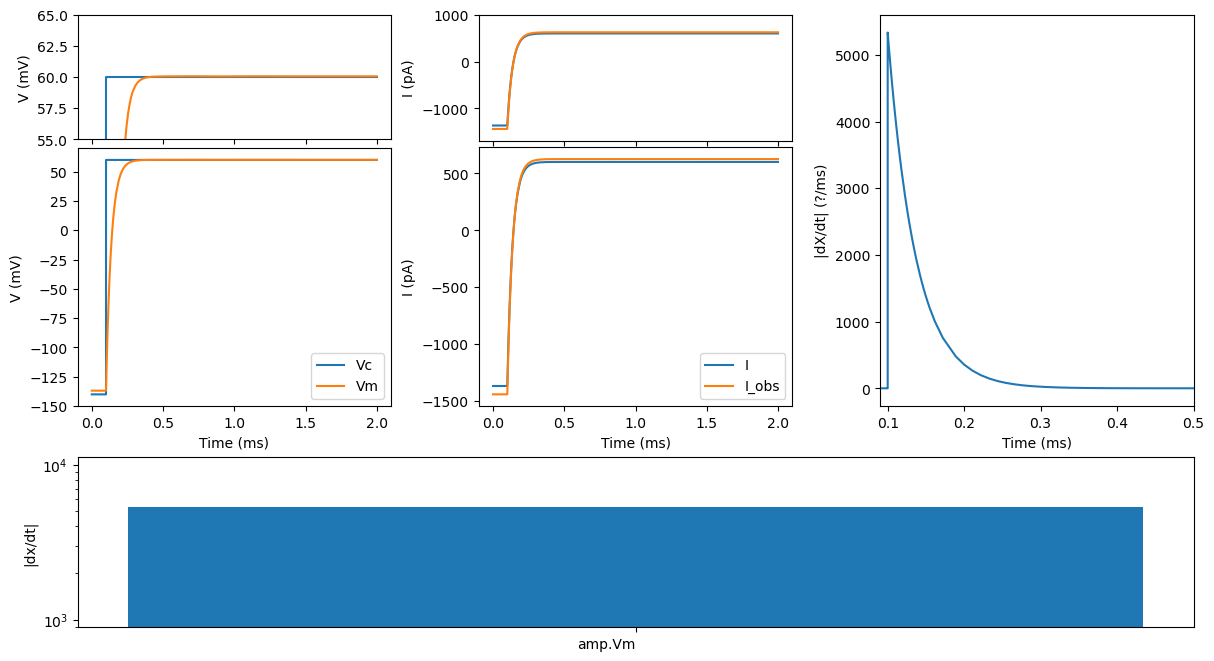

In [19]:
fig, axes = plot1(m5)

## Lei et al. 2025 model

The model presented in [Lei et al. 2025](https://doi.org/10.1002/advs.202500691) is similar to the level 1 simplification, but with two subtle differences:

- It uses a more abstract representation of the amplifier and its bandwidth correction
- It places the series resistance filter _after_ the summing amplifier.

<img src="./img/vc-lei-2025.png" />

_**Figure 2b**: Lei 2025 model, with an abstracted amplifier and a single 1-pole filter over the summed reference potential._

To derive the equations for this model, we start with $C_m\dot{V}_m$, for which we find the same relation as before:
\begin{align}
\text{Lei}25.3. && C_m\dot{V}_m = \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I
\end{align}
where "Lei25.3" indicates this is equation 3 from the 2025 Lei et al. paper.

For $V_p$, we now use the equation
\begin{align}
\text{Lei}25.4. && \dot{V}_p = \frac{V_r - V_p}{\tau_\text{clamp}}
\end{align}
to indicate that the applied voltage is $V_r$, low-pass filtered with some amplifier dependent time constant $\tau_\text{clamp}$.

For $V_r$, we use the same sum of components, but now with a filter on all three summed parts:
\begin{align}
\text{Lei}25.7. && \dot{V}_r &= \frac{V_c' - V_r}{\tau_\text{sum}} \\
\text{Lei}25.6. && V_c' &= V_c + \alpha R_s^* I_\text{out} + \beta R_s^* C_m^* \dot{V}_e
\end{align}

Series resistance prediction is the same as above
\begin{align}
\text{Lei}25.5. && \dot{V}_e &= \frac{V_c - V_e}{(1 - \beta)R_s^*C_m^*}   
\end{align}

The current "injected" by the amplifier is written as $I_\text{in}$, for which we find
\begin{align}
\text{Lei}25.8. && I_\text{in} = I + I_\text{leak} + C_m \dot{V}_m - C_m^* \dot{V}_e + C_p \dot{V}_p - C_p^* \dot{V}_r
\end{align}
which is similar to the current through $R_f$ and $C_f$ in the other models.

Finally, the observed current is filtered by the amplifier (intentionally and unintentionally) with a time constant $\tau_z$:
\begin{align}
\text{Lei}25.9. && I_\text{out} = \frac{I_\text{in} - I_\text{out}}{\tau_z}
\end{align}

This model is reimplemented in [vc-lei-2025.mmt](./res/vc-lei-2025.mmt).
The values used in this reimplementation were chosen to match the Level 1 simplification above.

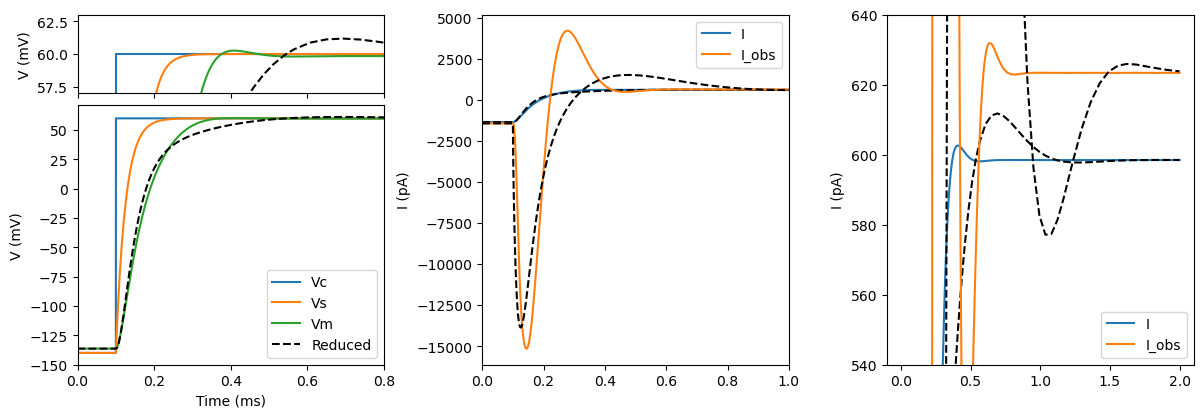

In [20]:
mlei25 = myokit.load_model('./res/vc-lei-2025.mmt')
fig, axes = plot2(m1, mlei25)

## Lei et al. 2020 model

The model by [Lei et al., 2020](https://doi.org/10.1098/rsta.2019.0348) is similar to the 2025 version, but does not include supercharging or a state estimator.

<img src="./img/vc-lei-2020.png" />

_**Figure 2b**: Lei 2020 model, without supercharging or state estimator._

To obtain equations for this model, we set $\beta = 0$ and set $\dot{V}_e = \dot{V}_r$ in Equation Lei20.2.6.

\begin{align}
\text{Lei}20.2.3. && C_m\dot{V}_m = \frac{V_p + E_\text{off}^\dagger - V_m}{R_s} - I_\text{leak} - I
\end{align}

\begin{align}
\text{Lei}20.2.4. && \dot{V}_p = \frac{V_r - V_p}{\tau_\text{clamp}}
\end{align}

\begin{align}
\text{Lei}20.2.5. && \dot{V}_r &= \frac{V_c + \alpha R_s^* I_\text{out} - V_r}{\tau_\text{sum}} \\
\end{align}

\begin{align}
\text{Lei}20.2.6. && I_\text{in} = I + I_\text{leak} + C_m \dot{V}_m - C_m^* \dot{V}_r + C_p \dot{V}_p - C_p^* \dot{V}_r
\end{align}

\begin{align}
\text{Lei}20.2.7. && I_\text{out} = \frac{I_\text{in} - I_\text{out}}{\tau_z}
\end{align}

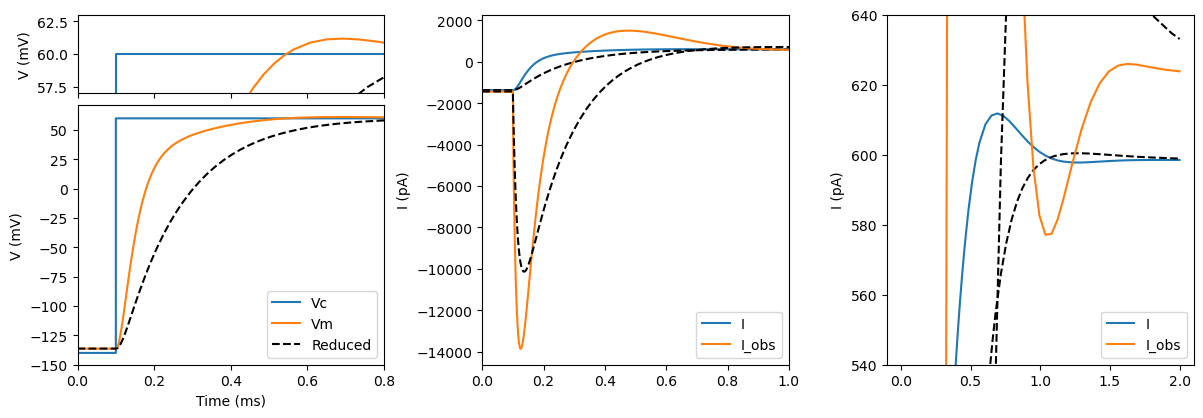

In [21]:
mlei20 = myokit.load_model('./res/vc-lei-2020.mmt')
mlei20.get('amp.tau_out').set_rhs(0.37)
mlei20.get('amp.tau_sum').set_rhs(0.02)
mlei20.get('amp.tau_clamp').set_rhs(1e-3)
fig, axes = plot2(mlei25, mlei20)

## Conclusion

In this notebook, we've taken the full model from the previous notebooks, and shown how successive permutations can lead to a series of simplified models:

1. The Level 1 simplification replaces all filters with 1-pole approximations.
2. The Level 2 simplification assumes an ideal op-amp and removes the stray capacitance $C_f$.
3. The Level 3 simplification assumes perfect $C_p$ cancellation.
4. The Level 4 simplification removes all filters entirely.
5. The Level 5 simplification assumes perfect $C_m$ cancellation (but still includes series resistance effects).

Finally, we compared the Lei et al. 2025 and 2020 models to those derived here.